# EDA And Preprocessing

## Data Loader

In [1]:
from dataset import CellPaintingDataset
from torch.utils.data import DataLoader

dataset = CellPaintingDataset(
    metadata_path="../data/processed/master_metadata.parquet",
    data_root="../data",
    channels=[1,2,3,4,5],
    tile_size=224
)

print("Num fields:", len(dataset.fields))   # ~14 or however many you have
print("Num tiles:", len(dataset))           # fields × 16

sample = dataset[0]
x = sample["image"]
print("Shape:", x.shape)        # should be (5, 224, 224)
print("Min:", x.min().item())
print("Max:", x.max().item())

Final valid fields: 864
Num fields: 5
Num tiles: 50000
Shape: torch.Size([5, 224, 224])
Min: 0.09422251582145691
Max: 1.2241250276565552


In [2]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch in loader:
    print(batch["image"].shape)
    print(batch["compound"][:3])
    break

torch.Size([4, 5, 224, 224])
['gabapentin-enacarbil', 'gabapentin-enacarbil', 'gabapentin-enacarbil']


## EDA

Note that:
* Ch1 Mito Mitochondria
* Ch2 AGP Actin, Golgi, Plasma membrane
* Ch3 RNA / Nucleoli
* Ch4 ER Endoplasmic Reticulum
* Ch5 DNA Nucleus (Hoechst 33342)


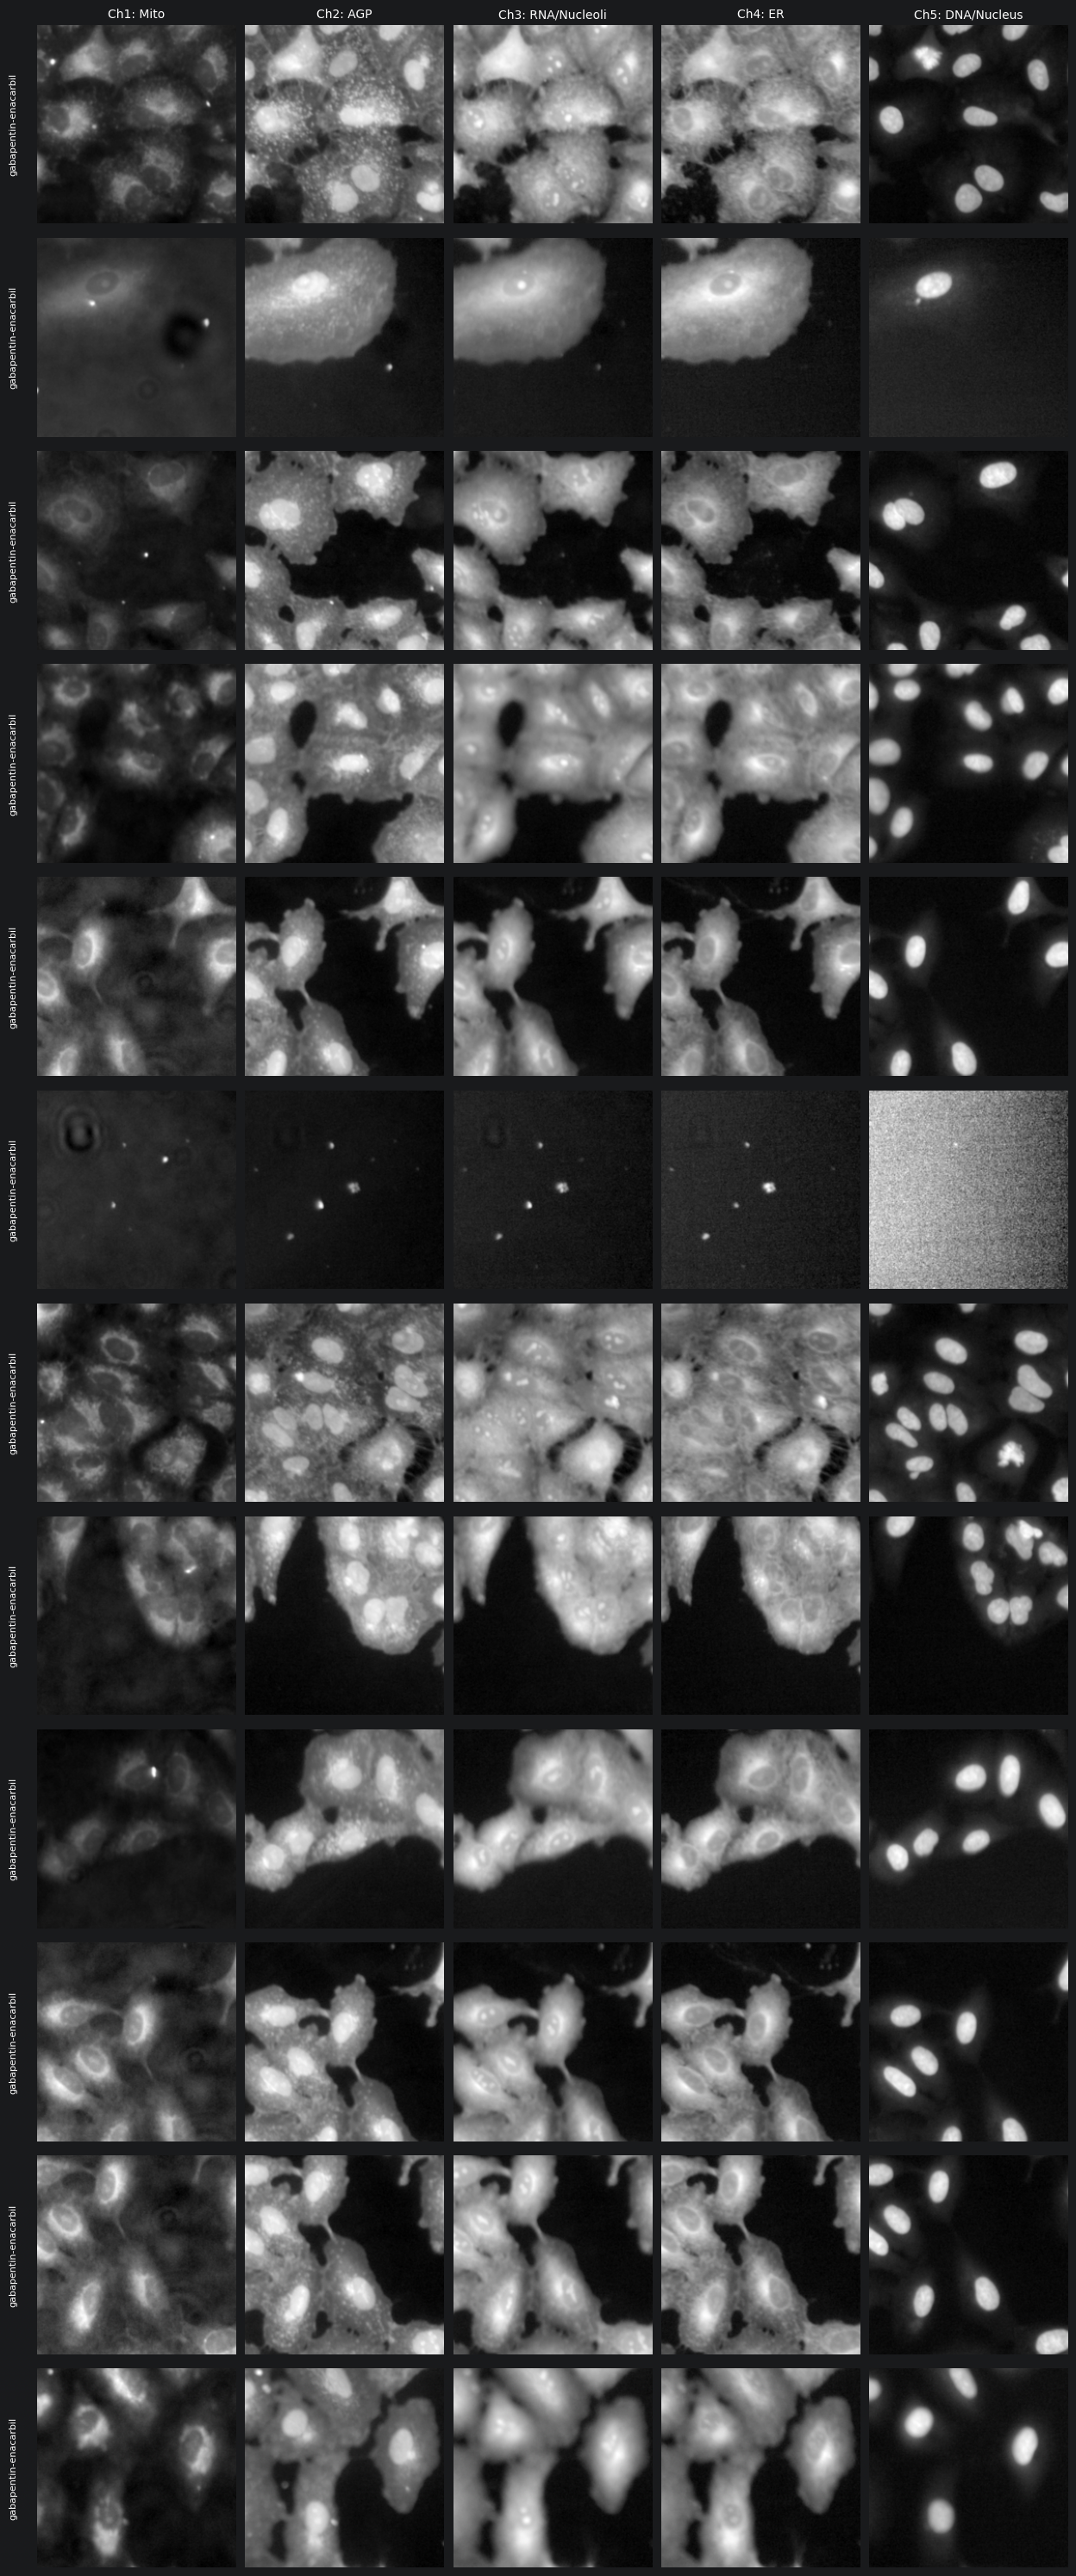

In [3]:
import matplotlib.pyplot as plt

def plot_grid(dataset, n=6, channel_names=None):

    sample = dataset[0]["image"]
    n_channels = sample.shape[0]

    fig, axes = plt.subplots(
        n, n_channels,
        figsize=(2.5 * n_channels, 2.5 * n)
    )

    if channel_names is None:
        channel_names = [f"Channel {c+1}" for c in range(n_channels)]

    for i in range(n):

        sample = dataset[i]
        x = sample["image"]

        for c in range(n_channels):
            ax = axes[i, c]

            ax.imshow(x[c], cmap="gray")
            ax.set_axis_off()

            if i == 0:
                ax.set_title(channel_names[c], fontsize=10)

        axes[i, 0].text(
            -0.1, 0.5,
            f"{sample['compound']}",
            rotation=90,
            transform=axes[i, 0].transAxes,
            va="center",
            ha="right",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

channels = ["Ch1: Mito", "Ch2: AGP", "Ch3: RNA/Nucleoli", "Ch4: ER", "Ch5: DNA/Nucleus"]

plot_grid(dataset, n=12, channel_names=channels)

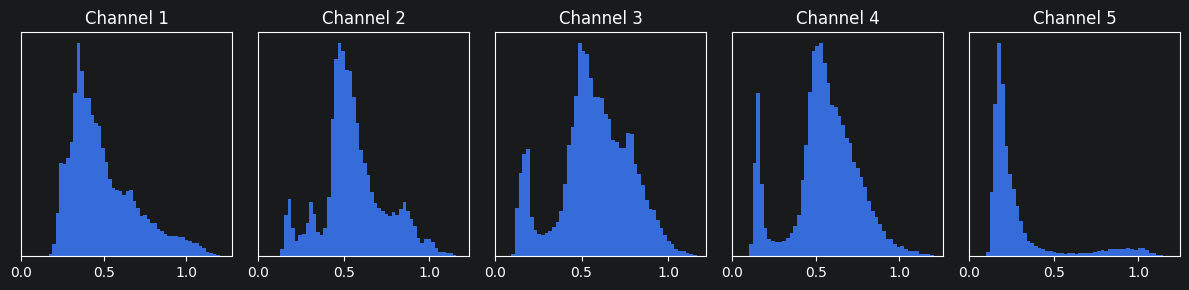

In [4]:
# Intensity distributions to check for normalization and corruption
import numpy as np

def plot_intensity_histograms(x):
    plt.figure(figsize=(12, 3))

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.hist(x[i].flatten(), bins=50)
        plt.title(f"Channel {i+1}")
        plt.xticks([0, 0.5, 1])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

plot_intensity_histograms(x)

100%|██████████| 500/500 [00:00<00:00, 507.27it/s]


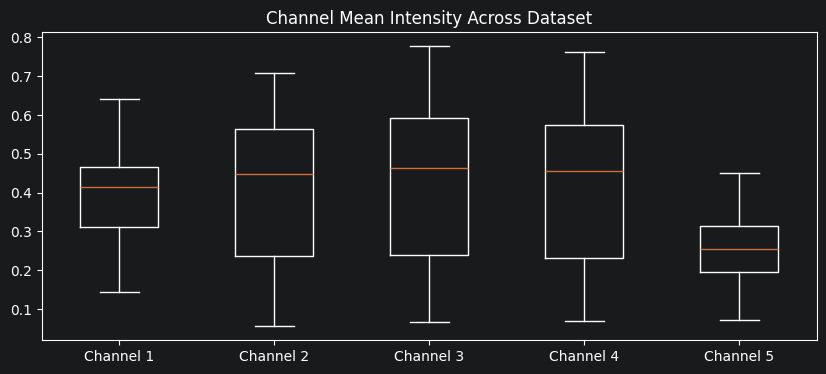

In [5]:
from tqdm import tqdm

# Subset-wide channel statistics
means = []
stds = []

subset = np.random.choice(len(dataset), min(len(dataset), 500), replace=False)

for i in tqdm(subset):
    sample = dataset[i]
    x = sample["image"]
    means.append(x.mean(dim=(1,2)).numpy())
    stds.append(x.std(dim=(1,2)).numpy())

means = np.stack(means)
stds = np.stack(stds)

plt.figure(figsize=(10,4))
plt.title("Channel Mean Intensity Across Dataset")
plt.boxplot(means)
plt.xticks(range(1,6), [f"Channel {i}" for i in range(1,6)])
plt.show()

In [6]:
import pandas as pd
print("Total rows:", len(dataset))

df = pd.read_parquet("../data/processed/master_metadata.parquet")

cols_to_check = [
    "pert_iname",
    "broad_sample",
    "plate",
    "well",
    "site",
    "gene",
    "control_type"
]

print("\n=== NULL / NaN COUNTS ===")

for col in cols_to_check:
    if col in df.columns:
        n_null = df[col].isna().sum()
        n_empty = (df[col] == "").sum() if df[col].dtype == "object" else 0
        print(f"{col:15s}  NaN: {n_null:6d}   Empty strings: {n_empty:6d}")
    else:
        print(f"{col:15s}  NOT FOUND")

print("\n=== SAMPLE BAD ROWS (if any) ===")

bad_mask = df[cols_to_check].isna().any(axis=1)
print("Bad rows:", bad_mask.sum())

print(df[bad_mask].head(10))

Total rows: 50000

=== NULL / NaN COUNTS ===
pert_iname       NaN:      0   Empty strings:      0
broad_sample     NaN:      0   Empty strings:      0
plate            NaN:      0   Empty strings:      0
well             NaN:      0   Empty strings:      0
site             NaN:      0   Empty strings:      0
gene             NaN:      0   Empty strings:      0
control_type     NaN:      0   Empty strings:      0

=== SAMPLE BAD ROWS (if any) ===
Bad rows: 0
Empty DataFrame
Columns: [url_origdna, url_origlowzbf, url_orighighzbf, url_origbrightfield, url_origmito, url_origagp, url_origer, url_origrna, plate, well, site, metadata_abspositionz, metadata_abstime, metadata_binningx, metadata_binningy, metadata_channelid, metadata_channelname, metadata_col, metadata_exposuretime, metadata_fieldid, metadata_imageresolutionx, metadata_imageresolutiony, metadata_imagesizex, metadata_imagesizey, metadata_mainemissionwavelength, metadata_mainexcitationwavelength, metadata_maxintensity, metadata_ob

In [7]:
# Find exact fields that will break DataLoader
problem_cols = []

for col in cols_to_check:
    if col in df.columns:
        if df[col].isna().any():
            problem_cols.append(col)

print("Columns causing None issues:", problem_cols)

Columns causing None issues: []
